# WSE Hawkes Calibration

Fit a 6-dimensional Hawkes process to WSE order flow with the
`HawkesCalibration` class in `research_core.classes`. The production model is
the single-exponential kernel; every figure in the thesis comes from it.

## Kernel

Each ordered pair of event types $(i, j)$ gets one exponential kernel
$\phi_{ij}(t) = \alpha_{ij}\,\beta_{ij}\,e^{-\beta_{ij} t}$. Optuna searches the
decay rates $\beta_{ij}$; `tick` then returns the baseline $\mu_i$ and the
adjacency $\alpha_{ij}$ by maximum likelihood.

## Event dimensions

`MO_bid`, `MO_ask`, `LO_bid`, `LO_ask`, `CXL_bid`, `CXL_ask`. By WSE convention
`MO_bid` is an aggressive buy and `MO_ask` an aggressive sell (see
`data/schema.py`).

## Steps

1. Extract order flow from HDF5 to SQLite (if not already done).
2. Estimate intraday seasonality profiles.
3. Multivariate single-exponential Hawkes, the production calibration.
4. Save the fitted parameters.

## Data setup

This notebook requires the WSELOB-2017 dataset. Download it from Mendeley Data
and place the HDF5 files under the repository's `data/` folder:

```
data/
└── WSELOB-2017/
    ├── orders/
    │   ├── KGHM_lob_2017_zlib.h5
    │   ├── PKNORLEN_lob_2017_zlib.h5
    │   ├── PKOBP_lob_2017_zlib.h5
    │   ├── PZU_lob_2017_zlib.h5
    │   └── PEKAO_lob_2017_zlib.h5
    └── trades/
        ├── KGHM_trades_2017_zlib.h5
        ├── PKNORLEN_trades_2017_zlib.h5
        ├── PKOBP_trades_2017_zlib.h5
        ├── PZU_trades_2017_zlib.h5
        └── PEKAO_trades_2017_zlib.h5
```

After the first run, extraction produces a per-asset SQLite database
(`<ASSET>_order_flow.sqlite`) in `data/` and subsequent runs load from there
directly.

**Source:**
Marszałek, Adam (2023), "WSELOB-2017: The year-long database of limit order
books for the five biggest companies listed on the Warsaw Stock Exchange",
Mendeley Data, V1, doi:
[10.17632/3g4mhdp899.1](https://data.mendeley.com/datasets/3g4mhdp899/1)

In [3]:
%pip install -e ..

Obtaining file:///C:/Users/jaspe/Documents/CLS/Thesis/test_thesis/thesisNote: you may need to restart the kernel to use updated packages.

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for research-core (pyproject.toml): started
  Building editable for research-core (pyproject.toml): finished with status 'done'
  Created wheel for research-core: filename=research_core-0.1.0-0.editable-py3-none-any.whl size=7187 sha256=a0acf23246923016fa3f3f601436c11256632e166110442ebb952dc673d401ef
  Stored in directory: C:\Users\jaspe\AppDa

DEPRECATION: pytorch-lightning 1.7.7 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [3]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from research_core.classes import (
    HawkesCalibration,
    compute_end_times,
    list_day_keys,
    load_events_from_sqlite_bulk,
    load_extraction_stats,
    estimate_seasonality_profiles,
    data_dir,
    run_full_extraction
)
from research_core.classes.calibrate import (
    get_average_seasonality_shape,
    plot_all_seasonality_patterns,
)

In [4]:
assets = {"KGHM": 10783, "PKNORLEN": 11319, "PKOBP": 11314, "PZU": 10735, "PEKAO": 11322}

asset = "KGHM"

# Evaluation window: skip the first day_start_idx sessions (warm-up / illiquid
# listing days), then take n_days. Extraction and the bulk loader use this same
# window.
n_days = 229
day_start_idx = 6

tick_size = 0.05

market_open = "09:00:00"
market_close = "16:50:00"

marks_order = ["MO_bid", "MO_ask", "LO_bid", "LO_ask", "CXL_bid", "CXL_ask"]

max_iter = 1_000_000
tol = 1e-9

gof_dims = ["LO_bid", "MO_bid"]

data_path = data_dir()

force_reextract = False


In [5]:
db_path = data_path / f"{asset}_order_flow.sqlite"
wselob_dir = data_path / "WSELOB-2017"
orders_h5 = wselob_dir / "orders" / f"{asset}_lob_2017_zlib.h5"
trades_h5 = wselob_dir / "trades" / f"{asset}_trades_2017_zlib.h5"

all_days = list_day_keys(asset)
selected_days = all_days[day_start_idx : day_start_idx + n_days]
print(f"Day window: {selected_days[0]} .. {selected_days[-1]} ({len(selected_days)} days)")

if force_reextract or not db_path.exists():
    run_full_extraction(
        asset, orders_h5, trades_h5, db_path,
        market_open=market_open,
        market_close=market_close,
        tick_size=tick_size,
        force=force_reextract,
        day_keys=selected_days,
    )
else:
    print(f"SQLite DB already exists: {db_path}  (set force_reextract=True to rebuild)")


Day window: d20170119 .. d20171206 (223 days)
SQLite DB already exists: C:\Users\jaspe\Documents\CLS\Thesis\test_thesis\thesis\data\KGHM_order_flow.sqlite  (set force_reextract=True to rebuild)


In [ ]:
day_keys = list_day_keys(asset)[day_start_idx : day_start_idx + n_days]
print(f"Selected {len(day_keys)} days: {day_keys[0]} .. {day_keys[-1]}")

print(f"\nBulk-loading events from SQLite ({len(day_keys)} days)...")
t0 = time.time()
timestamps_by_day = load_events_from_sqlite_bulk(db_path, day_keys, market_open, marks_order,)
print(f"Bulk load complete in {time.time() - t0:.2f}s")

for dk, day_seq in [(day_keys[0], timestamps_by_day[0]), (day_keys[-1], timestamps_by_day[-1])]:
    counts = {m: len(s) for m, s in zip(marks_order, day_seq)}
    max_t = max((s.max() if len(s) else 0.0) for s in day_seq)
    print(f"  {dk}: {counts}  total={sum(counts.values())}  max_t={max_t:.2f}")

end_times = compute_end_times(timestamps_by_day)
print(f"\nDays: {len(timestamps_by_day)}, max end time: {end_times.max():.2f} s")


Selected 223 days: d20170119 .. d20171206

Bulk-loading events from SQLite (223 days)...
Bulk load complete in 146.68s
  d20170119: {'MO_bid': 2107, 'MO_ask': 2030, 'LO_bid': 34323, 'LO_ask': 34927, 'CXL_bid': 33463, 'CXL_ask': 34527}  total=141377  max_t=28199.13
  d20171206: {'MO_bid': 1878, 'MO_ask': 1656, 'LO_bid': 29140, 'LO_ask': 24508, 'CXL_bid': 28112, 'CXL_ask': 24144}  total=109438  max_t=28199.51

Days: 223, max end time: 28200.00 s


# Dataset statistics

Two summary tables describing the extracted data that feeds the calibration:

- **Market activity statistics** — event counts by type (limit order
  submissions, aggregated market orders, cancellations) and the total order
  message count.
- **Trade filtering and classification statistics** — raw fills, the number of
  aggregated market orders they collapse into, and the Lee-Ready rule
  (quote / midpoint / tick) that classified each fill.

Both come from the statistics `run_full_extraction` accumulates while it builds
each database and persists to a small `<ASSET>_order_flow_stats.json` sidecar,
so there is no re-querying of the SQLite tables here. The cell aggregates across
every asset that has a sidecar, so with all five assets extracted it reproduces
the full-dataset thesis tables; with only the current asset it reports that
asset.


In [7]:
# Statistics that extraction already computed, read back from the per-asset
# summary sidecars written by run_full_extraction (not re-derived from the DB).
summaries = []
for asset_name in assets:
    stats = load_extraction_stats(data_path / f"{asset_name}_order_flow.sqlite")
    if stats is not None:
        summaries.append(stats)

if not summaries:
    print( "No extraction statistics found. Run the extraction cell with "
        "force_reextract=True to generate the summary sidecars.")
else:
    assets_used = [s["asset"] for s in summaries]
    counts = {
        mark: sum(s["event_counts"][mark] for s in summaries)
        for mark in ("LO_bid", "LO_ask", "MO_bid", "MO_ask", "CXL_bid", "CXL_ask")
    }
    cls = {
        rule: sum(s["classification"][rule] for s in summaries)
        for rule in ("quote", "midpoint", "tick", "last_side", "n_trades")
    }
    n_mos = sum(s["n_mos"] for s in summaries)

    print(f"Assets aggregated ({len(assets_used)}): {', '.join(assets_used)}")

    # --- Table: Market activity statistics ---
    market_activity = pd.DataFrame(
        [
            ("Limit order submissions (bid)", counts["LO_bid"]),
            ("Limit order submissions (ask)", counts["LO_ask"]),
            ("Market orders (buy)", counts["MO_bid"]),
            ("Market orders (sell)", counts["MO_ask"]),
            ("Cancellations (bid)", counts["CXL_bid"]),
            ("Cancellations (ask)", counts["CXL_ask"]),
            ("Total order messages", sum(counts.values())),
        ],
        columns=["Event type", "Total"],
    )
    print("\nMarket activity statistics")
    print(market_activity.to_string(index=False, formatters={"Total": "{:,}".format}))

    # --- Table: Trade filtering and classification statistics ---
    raw_fills = cls["n_trades"]
    n_unclassified = raw_fills - cls["quote"] - cls["midpoint"] - cls["tick"] - cls["last_side"]

    def _share(count):
        return f"{100.0 * count / raw_fills:.1f}%" if raw_fills else "n/a"

    trade_classification = pd.DataFrame(
        [
            ("Raw trades (fills)", f"{raw_fills:,}"),
            ("Aggregated market orders", f"{n_mos:,}"),
            ("Quote rule", f"{cls['quote']:,}"),
            ("Midpoint rule", f"{cls['midpoint']:,}"),
            ("Tick rule", f"{cls['tick']:,}"),
            ("Unclassified", f"{n_unclassified:,}"),
            ("% Quote", _share(cls["quote"])),
            ("% Midpoint", _share(cls["midpoint"])),
            ("% Tick", _share(cls["tick"])),
        ],
        columns=["Statistic", "Total"],
    )
    print("\nTrade filtering and classification statistics")
    print(trade_classification.to_string(index=False))


Assets aggregated (1): KGHM

Market activity statistics
                   Event type      Total
Limit order submissions (bid)  4,494,918
Limit order submissions (ask)  4,507,109
          Market orders (buy)    353,092
         Market orders (sell)    332,601
          Cancellations (bid)  4,387,840
          Cancellations (ask)  4,443,325
         Total order messages 18,518,885

Trade filtering and classification statistics
               Statistic     Total
      Raw trades (fills) 1,156,590
Aggregated market orders   685,693
              Quote rule 1,089,745
           Midpoint rule    13,742
               Tick rule    52,991
            Unclassified       112
                 % Quote     94.2%
              % Midpoint      1.2%
                  % Tick      4.6%


# Intraday Seasonality Estimation

We estimate a nonparametric intraday intensity profile $s^{(k)}(t)$ for each event type using an Epanechnikov kernel,
normalised so that $\frac{1}{T}\int_0^T s^{(k)}(t)\,dt = 1$.

The average shape across all event types is then used to construct a shared time transformation
$\tau(t) = \int_0^t \bar{s}(u)\,du$ that removes deterministic clock-time variation.

In [8]:
seasonality_bandwidth = 300.0
seasonality_grid_points = 400
force_seasonality_recompute = False

seasonality_cache_dir = data_path / "seasonality_cache"
seasonality_cache_path = seasonality_cache_dir / f"{asset}_seasonality_profiles.pkl"

# Use ALL available days for seasonality estimation (not just the calibration subset)
all_day_keys_season = list_day_keys(asset)
print(f"Loading ALL {len(all_day_keys_season)} days for seasonality estimation...")

t0 = time.time()
all_ts_season = load_events_from_sqlite_bulk(db_path, all_day_keys_season, market_open, marks_order)
all_end_times_season = compute_end_times(all_ts_season)
print(f"Loaded in {time.time() - t0:.2f}s")

seasonality_profiles = estimate_seasonality_profiles(
    all_ts_season,
    marks_order,
    all_end_times_season,
    bandwidth=seasonality_bandwidth,
    grid_points=seasonality_grid_points,
    cache_path=seasonality_cache_path,
    force_recompute=force_seasonality_recompute,
)


Loading ALL 229 days for seasonality estimation...
Loaded in 141.30s



1. Correlation with average pattern:
   Event Type    Correlation      p-value       RMSE
   ------------------------------------------------
   MO_bid             0.9339   7.57e-180***     0.1448
   MO_ask             0.9570   4.20e-216***     0.1220
   LO_bid             0.9774   7.92e-271***     0.0636
   LO_ask             0.9769   6.66e-269***     0.0626
   CXL_bid            0.9718   7.00e-252***     0.0708
   CXL_ask            0.9742   2.53e-259***     0.0665

2. Summary statistics:
   Mean correlation with average: 0.9652
   Min correlation with average:  0.9339
   Mean pairwise correlation:     0.9200
   Min pairwise correlation:      0.8255


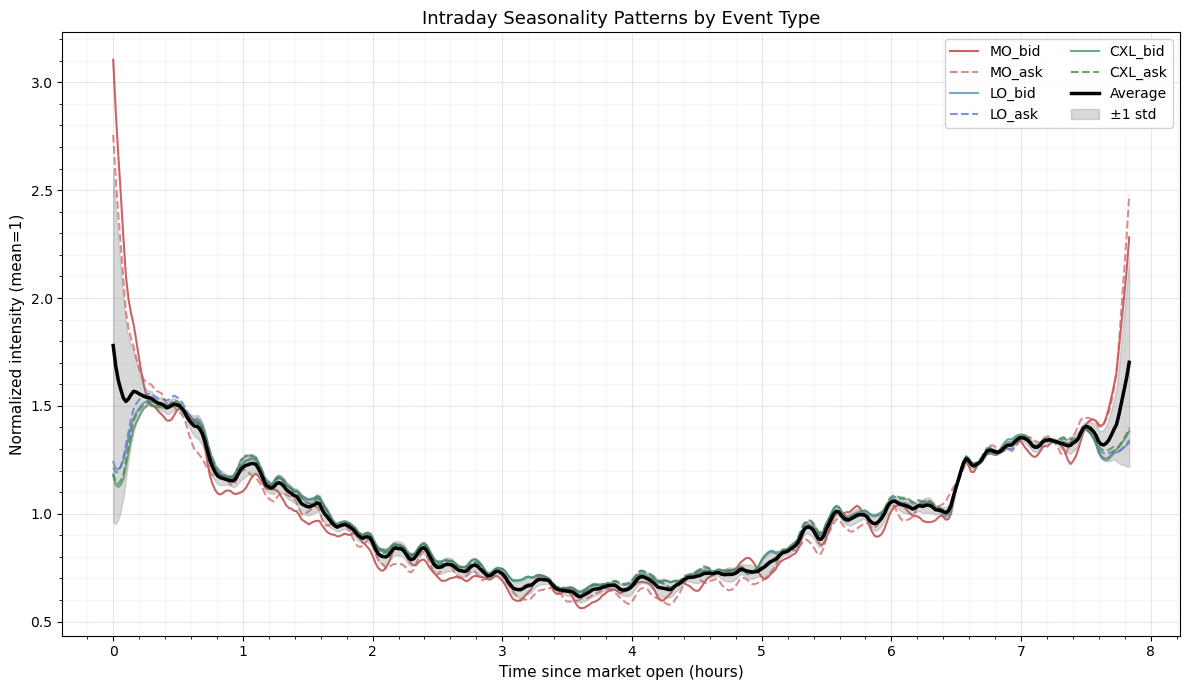

Average seasonality grid points: 400
Total tau at end of day: 28147.6349


In [9]:
fig, ax, seasonal_stats = plot_all_seasonality_patterns(seasonality_profiles, marks_order=marks_order, normalize=True, show_average=True, show_uncertainty=True)
plt.show()

avg_seasonality = get_average_seasonality_shape(seasonality_profiles, marks_order=marks_order, normalize=True)
print(f"Average seasonality grid points: {len(avg_seasonality['grid'])}")
print(f"Total tau at end of day: {avg_seasonality['cumulative_integral'][-1]:.4f}")

## Instantiate HawkesCalibration

All subsequent calibrations are run through a single `HawkesCalibration` instance.
By passing `seasonality_profiles`, the class automatically builds the shared average
$\tau$-time transformation internally. Methods accept `use_tau=True/False`.

In [10]:
cal = HawkesCalibration(timestamps_by_day=timestamps_by_day, marks_order=marks_order, end_times=end_times, seasonality_profiles=seasonality_profiles, max_iter=max_iter, tol=tol)

print("HawkesCalibration ready:")
print(f"  Dimensions:   {cal.n_nodes}")
print(f"  Days:         {cal.n_days}")
print(f"  Marks:        {cal.marks_order}")
print(f"  Seasonality:  {'yes' if cal.seasonality_profiles else 'no'}")

HawkesCalibration ready:
  Dimensions:   6
  Days:         223
  Marks:        ['MO_bid', 'MO_ask', 'LO_bid', 'LO_ask', 'CXL_bid', 'CXL_ask']
  Seasonality:  yes


[I 2026-07-09 16:38:51,232] A new study created in RDB with name: hawkes_single_multi_τ-time_1783607930


Launched 12 workers (84 trials each, single)
[W7] c:\Users\jaspe\anaconda3\lib\runpy.py:127: RuntimeWarning: 'research_core.classes.parallelisation' found in sys.modules after import of package 'research_core.classes', but prior to execution of 'research_core.classes.parallelisation'; this may result in unpredictable behaviour
[W7]   warn(RuntimeWarning(msg))
[W7] Worker 7 starting (84 trials, single)
[W11] c:\Users\jaspe\anaconda3\lib\runpy.py:127: RuntimeWarning: 'research_core.classes.parallelisation' found in sys.modules after import of package 'research_core.classes', but prior to execution of 'research_core.classes.parallelisation'; this may result in unpredictable behaviour
[W11]   warn(RuntimeWarning(msg))
[W4] c:\Users\jaspe\anaconda3\lib\runpy.py:127: RuntimeWarning: 'research_core.classes.parallelisation' found in sys.modules after import of package 'research_core.classes', but prior to execution of 'research_core.classes.parallelisation'; this may result in unpredictable be

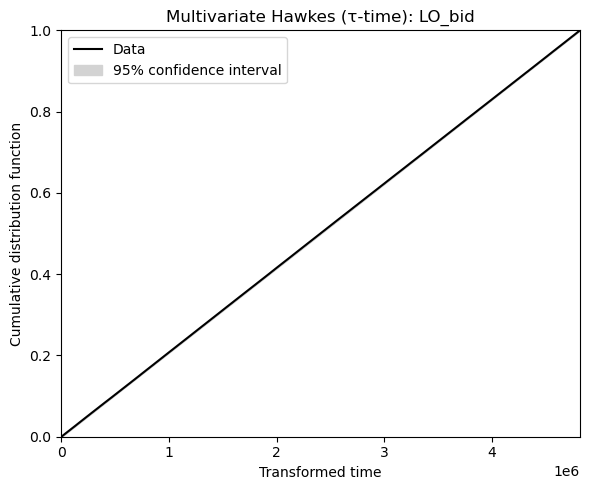

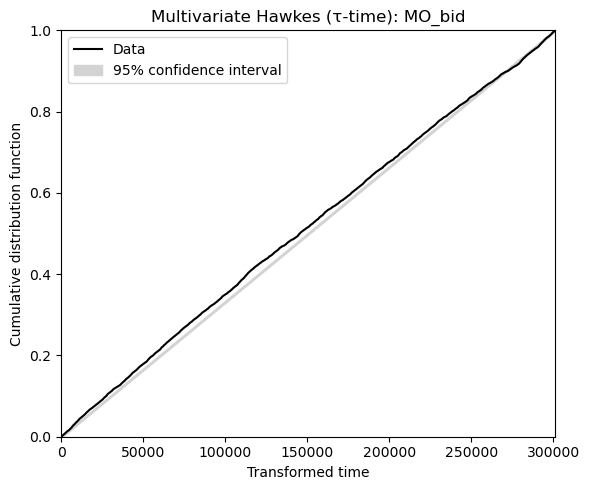

NameError: name 'n_nodes' is not defined

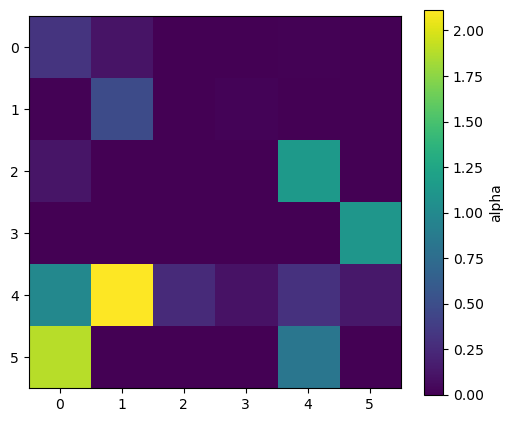

In [ ]:
multi_single_tau = cal.fit_multivariate_hawkes(use_tau=True, n_trials=1000, n_workers=12, beta_min=0.1, beta_max=20.0, gof_dims=gof_dims)


In [1]:
plt.figure(figsize=(6, 5))
plt.imshow(multi_single_tau["adjacency"], cmap="viridis")
plt.colorbar(label="alpha")
plt.xticks(range(6), marks_order, rotation=45)
plt.yticks(range(6), marks_order)
plt.title(r"Adjacency matrix $\alpha$ ($\tau$-time)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(multi_single_tau["decays"], cmap="viridis")
plt.colorbar(label="beta")
plt.xticks(range(6), marks_order, rotation=45)
plt.yticks(range(6), marks_order)
plt.title(r"Decay matrix $\beta$ ($\tau$-time)")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## Save calibrated parameters

All fitted parameter sets are saved to pickle files for downstream use
(simulation, analysis, etc.).

In [12]:
HawkesCalibration.save_params(
    f"multivariate_hawkes_params_{asset}.pkl",
    marks=marks_order,
    baseline=multi_single_tau["baseline"],
    adjacency=multi_single_tau["adjacency"],
    decays=multi_single_tau["decays"],
)

core_results = {
    "asset": asset,
    "marks_order": marks_order,
    "n_days": len(day_keys),
    "day_keys": day_keys,
    "multi_single_tau": {k: v for k, v in multi_single_tau.items() if k != "model"},
}

HawkesCalibration.save_params(f"hawkes_calibration_full_{asset}.pkl",**core_results)

print("\nSingle-exponential calibration saved.")

Saved: C:\Users\jaspe\Documents\CLS\Thesis\test_thesis\thesis\data\multivariate_hawkes_params_KGHM.pkl
Saved: C:\Users\jaspe\Documents\CLS\Thesis\test_thesis\thesis\data\hawkes_calibration_full_KGHM.pkl

Single-exponential calibration saved.
